# Selección de líneas para 2008: análisis final

**Decisión:** en enero de 2008 se recortaron las parcelas y hay que elegir qué líneas nuevas (de las ~16 000 que se van a sembrar) merecen avanzar. Este documento evalúa, con honestidad, **qué tan bien el modelo de dos niveles (familia + dentro de familia) ordena esas líneas**, contra los rendimientos que realmente se observaron en 2008.

**Cómo leerlo**
- **C1 y C2 se analizan por separado**, como programas independientes. Nunca se muestran cifras combinadas.
- **Todas las cifras de exactitud usan solo información disponible en enero de 2008.** Los rendimientos de 2008 se usan únicamente como "respuesta correcta" para puntuar.
- El modelo y su validación hacia adelante (2004–2007, más 2008 como examen) son del pipeline de `etapa1/` y `etapa2/`. Aquí se **recalcula y verifica** la exactitud desde sus archivos de predicciones, con intervalos por remuestreo de familias, y se agregan la separación del efecto del tester, el análisis de sitios y de presupuesto, y la evidencia de marcadores.
- Los intervalos de confianza son del 95% por remuestreo de familias (cada familia es una unidad independiente).

**Archivos que necesita** (todos ya generados): resultados de `etapa1/resultados` y `etapa2/resultados`; `site_analysis.py` (sitios y presupuesto, C1 y C2 por separado), `marker_candidates.py` (efectos por SNP, solo C1) y el resumen de evidencia de `proposal_2007.ipynb`. Si falta alguno, la sección correspondiente se omite.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "DIGITALTOOL").is_dir():
            return d
    raise FileNotFoundError("Run the notebook from inside the Hackolombia repo")


BASE = find_root(Path.cwd().resolve())
RES1, RES2 = BASE / "etapa1" / "resultados", BASE / "etapa2" / "resultados"
MINE = BASE / "DIGITALTOOL" / "data" / "processed" / "prediction"
FIN = MINE / "final_analysis"

COL = {"C1": "#2a78d6", "C2": "#eb6834"}
INK, MUTED = "#0b0b0b", "#898781"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
                     "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
                     "legend.frameon": False, "axes.axisbelow": True})
N_BOOT = 1000
CLUSTERS = ["C1", "C2"]

K = pd.read_csv(RES2 / "ranking_2008_with_answer_key.csv").dropna(subset=["YLD_OBS_BLUE"]).reset_index(drop=True)
S = pd.read_csv(RES2 / "stage2_scores.csv")
strat = pd.read_csv(RES2 / "selection_strategies.csv")
S = S[S.trait == "YLD_BE"]
vc = pd.read_csv(RES1 / "varcomp.csv")
qc = {n: json.load(open(RES1 / f"qc_{n}.json")) for n in ("phenotypes", "line_values", "genotypes", "environment")}
print({c: f"{(K.CLUSTER == c).sum()} lines, {K[K.CLUSTER == c].POP.nunique()} families" for c in CLUSTERS})

{'C1': '7429 lines, 71 families', 'C2': '8532 lines, 86 families'}


## 1. Exactitud final en 2008, por cluster

Se comparan las predicciones (hechas con datos ≤ 2007) contra el rendimiento observado en 2008 de cada línea. Primero cifras que no dependen de cuántas líneas se avance, y luego el efecto de distintos presupuestos.

In [2]:
GRID = np.round(np.arange(0.05, 0.5001, 0.05), 2)     # budgets 5% ... 50%
BUDGETS = [0.05, 0.10, 0.20, 0.30, 0.50]              # shown side by side; none is "the" budget
BEST = 0.10                                            # "the best lines" = the true top 10% of the year


def sel_stats(p, o, fracs, best=BEST):
    """For each budget: share of the truly best lines kept, precision, gain and % of the maximum gain."""
    n = len(o)
    order = np.argsort(-p)
    kt = int(round(n * best))
    is_best = np.zeros(n, bool)
    is_best[np.argsort(-o)[:kt]] = True
    ks = np.maximum(1, np.round(np.asarray(fracs) * n).astype(int))
    hit = np.cumsum(is_best[order])[ks - 1]
    gain = np.cumsum(o[order])[ks - 1] / ks - o.mean()
    gmax = np.cumsum(np.sort(o)[::-1])[ks - 1] / ks - o.mean()
    return dict(recall=hit / kt, precision=hit / ks, gain=gain, gain_pct=100 * gain / gmax)


def cluster_metrics(g, n_boot=N_BOOT, seed=0):
    p, o = g.YLD_PRED.to_numpy(), g.YLD_OBS_BLUE.to_numpy()
    fam = [np.where(g.POP.to_numpy() == f)[0] for f in g.POP.unique()]
    rng = np.random.default_rng(seed)

    def point(idx):
        pp, oo, gg = p[idx], o[idx], g.iloc[idx]
        f = gg.groupby("POP")[["YLD_PRED", "YLD_OBS_BLUE"]].mean()
        pc = pp - gg.groupby("TESTER").YLD_PRED.transform("mean").to_numpy()
        oc = oo - gg.groupby("TESTER").YLD_OBS_BLUE.transform("mean").to_numpy()
        sg, sb = sel_stats(pp, oo, GRID), sel_stats(pp, oo, BUDGETS)
        return dict(r_lines=np.corrcoef(pp, oo)[0, 1],
                    rho_lines=np.corrcoef(pd.Series(pp).rank(), pd.Series(oo).rank())[0, 1],
                    r_family=np.corrcoef(f.YLD_PRED, f.YLD_OBS_BLUE)[0, 1],
                    r_lines_within_tester=np.corrcoef(pc, oc)[0, 1],
                    mean_gain_pct=sg["gain_pct"].mean(),
                    recall_b=sb["recall"], gain_pct_b=sb["gain_pct"], gain_b=sb["gain"], precision_b=sb["precision"])

    est = point(np.arange(len(g)))
    boots = [point(np.concatenate([fam[i] for i in rng.integers(0, len(fam), len(fam))])) for _ in range(n_boot)]
    scalar = pd.DataFrame([{k: v for k, v in b.items() if not k.endswith("_b")} for b in boots])
    arrays = {k: np.array([b[k] for b in boots]) for k in est if k.endswith("_b")}
    return est, scalar, arrays


H, HB, HA = {}, {}, {}
for c in CLUSTERS:
    H[c], HB[c], HA[c] = cluster_metrics(K[K.CLUSTER == c].reset_index(drop=True))


def ci(c, key, scale=1.0, dec=0):
    lo, hi = HB[c][key].quantile(0.025), HB[c][key].quantile(0.975)
    return f"{scale * H[c][key]:.{dec}f}  (IC {scale * lo:.{dec}f} a {scale * hi:.{dec}f})"


rows = {
    "Líneas / familias evaluadas": {c: f"{(K.CLUSTER == c).sum():,} / {K[K.CLUSTER == c].POP.nunique()}" for c in CLUSTERS},
    "Varianza explicada en líneas, con tester (R², %)": {c: f"{100 * H[c]['r_lines'] ** 2:.0f}%  (r = {H[c]['r_lines']:.2f}; IC {HB[c]['r_lines'].quantile(.025):.2f} a {HB[c]['r_lines'].quantile(.975):.2f})" for c in CLUSTERS},
    "Varianza explicada en líneas, comparando dentro de cada tester (R², %)": {c: f"{100 * H[c]['r_lines_within_tester'] ** 2:.0f}%  (r = {H[c]['r_lines_within_tester']:.2f}; IC {HB[c]['r_lines_within_tester'].quantile(.025):.2f} a {HB[c]['r_lines_within_tester'].quantile(.975):.2f})" for c in CLUSTERS},
    "Varianza explicada en medias de familia, con tester (R², %)": {c: f"{100 * H[c]['r_family'] ** 2:.0f}%  (r = {H[c]['r_family']:.2f})" for c in CLUSTERS},
    "Correlación de rangos (Spearman) de las líneas": {c: ci(c, "rho_lines", dec=2) for c in CLUSTERS},
    "% de la ganancia máxima posible, promediado sobre presupuestos de 5% a 50%": {c: ci(c, "mean_gain_pct") + "%" for c in CLUSTERS},
}
headline = pd.DataFrame(rows).T
headline.to_csv(FIN / "headline_accuracy.csv") if FIN.exists() else None

# The same accuracy for several budgets (fraction of lines advanced), all shown equally
bt = []
for c in CLUSTERS:
    for j, q in enumerate(BUDGETS):
        rec, gp = HA[c]["recall_b"][:, j], HA[c]["gain_pct_b"][:, j]
        bt.append({"cluster": c, "se avanza": f"{int(q * 100)}%",
                   "captura de las mejores 10% reales (azar = presupuesto)": f"{100 * H[c]['recall_b'][j]:.0f}%  (IC {100 * np.percentile(rec, 2.5):.0f}% a {100 * np.percentile(rec, 97.5):.0f}%)",
                   "% de la ganancia máxima": f"{H[c]['gain_pct_b'][j]:.0f}%  (IC {np.percentile(gp, 2.5):.0f}% a {np.percentile(gp, 97.5):.0f}%)",
                   "ganancia (bu/ac)": f"{H[c]['gain_b'][j]:+.1f}",
                   "precisión (de lo avanzado, % que es top-10% real)": f"{100 * H[c]['precision_b'][j]:.0f}%"})
budget_table = pd.DataFrame(bt).set_index(["cluster", "se avanza"])
display(headline)
budget_table

,C1,C2
Líneas / familias evaluadas,"7,429 / 71","8,532 / 86"
"Varianza explicada en líneas, con tester (R², %)",12% (r = 0.34; IC 0.18 a 0.49),40% (r = 0.64; IC 0.50 a 0.73)
"Varianza explicada en líneas, comparando dentro de cada tester (R², %)",3% (r = 0.18; IC 0.09 a 0.27),6% (r = 0.25; IC 0.13 a 0.36)
"Varianza explicada en medias de familia, con tester (R², %)",12% (r = 0.34),49% (r = 0.70)
Correlación de rangos (Spearman) de las líneas,0.38 (IC 0.21 a 0.53),0.62 (IC 0.49 a 0.71)
"% de la ganancia máxima posible, promediado sobre presupuestos de 5% a 50%",35 (IC 14 a 55)%,63 (IC 52 a 71)%


captura de las mejores 10% reales (azar = presupuesto)  \
cluster se avanza                                                          
C1      5%                                         2%  (IC 0% a 16%)       
        10%                                       22%  (IC 3% a 42%)       
        20%                                      56%  (IC 33% a 76%)       
        30%                                      78%  (IC 55% a 94%)       
        50%                                      96%  (IC 85% a 99%)       
C2      5%                                        17%  (IC 9% a 27%)       
        10%                                      30%  (IC 18% a 42%)       
        20%                                      51%  (IC 36% a 66%)       
        30%                                      66%  (IC 52% a 81%)       
        50%                                      91%  (IC 82% a 98%)       

                  % de la ganancia máxima ganancia (bu/ac)  \
cluster se avanza                                            
C1      5%          -12%  (IC -35% a 32%)             -4.6   
        10%          16%  (IC -17% a 46%)             +5.2   
        20%            36%  (IC 9% a 58%)             +9.0   
        30%           42%  (IC 17% a 65%)             +8.2   
        50%           52%  (IC 31% a 67%)             +6.4   
C2      5%            56%  (IC 42% a 71%)            +19.1   
        10%           57%  (IC 44% a 69%)            +17.1   
        20%           60%  (IC 47% a 70%)            +14.8   
        30%           64%  (IC 51% a 73%)            +13.4   
        50%           69%  (IC 56% a 78%)            +10.7   

                  precisión (de lo avanzado, % que es top-10% real)  
cluster se avanza                                                    
C1      5%                                                       3%  
        10%                                                     22%  
        20%                                                     28%  
        30%                                                     26%  
        50%                                                     19%  
C2      5%                                                      34%  
        10%                                                     30%  
        20%                                                     25%  
        30%                                                     22%  
        50%                                                     18%

In [3]:
display(Markdown(f"""
### Resumen de exactitud (2008): cifras que no dependen de ningún presupuesto

| | **C1** | **C2** |
|---|---|---|
| Varianza explicada en líneas, **con** efecto del tester | **{100*H['C1']['r_lines']**2:.0f}%** | **{100*H['C2']['r_lines']**2:.0f}%** |
| Varianza explicada en líneas, **sin** efecto del tester | **{100*H['C1']['r_lines_within_tester']**2:.0f}%** | **{100*H['C2']['r_lines_within_tester']**2:.0f}%** |
| Correlación de rangos (Spearman) | **{H['C1']['rho_lines']:.2f}** | **{H['C2']['rho_lines']:.2f}** |
| % de la ganancia máxima, promediado sobre presupuestos de 5% a 50% | **{H['C1']['mean_gain_pct']:.0f}%** | **{H['C2']['mean_gain_pct']:.0f}%** |

La cifra "sin tester" es un **límite inferior** de la exactitud genética: al comparar dentro de cada tester también se descarta cualquier diferencia real entre familias asociada al tester. La exactitud genética verdadera queda entre las dos cifras. La tabla de arriba muestra el efecto de distintos presupuestos; el reto no fija ninguno.
"""))


### Resumen de exactitud (2008): cifras que no dependen de ningún presupuesto

| | **C1** | **C2** |
|---|---|---|
| Varianza explicada en líneas, **con** efecto del tester | **12%** | **40%** |
| Varianza explicada en líneas, **sin** efecto del tester | **3%** | **6%** |
| Correlación de rangos (Spearman) | **0.38** | **0.62** |
| % de la ganancia máxima, promediado sobre presupuestos de 5% a 50% | **35%** | **63%** |

La cifra "sin tester" es un **límite inferior** de la exactitud genética: al comparar dentro de cada tester también se descarta cualquier diferencia real entre familias asociada al tester. La exactitud genética verdadera queda entre las dos cifras. La tabla de arriba muestra el efecto de distintos presupuestos; el reto no fija ninguno.


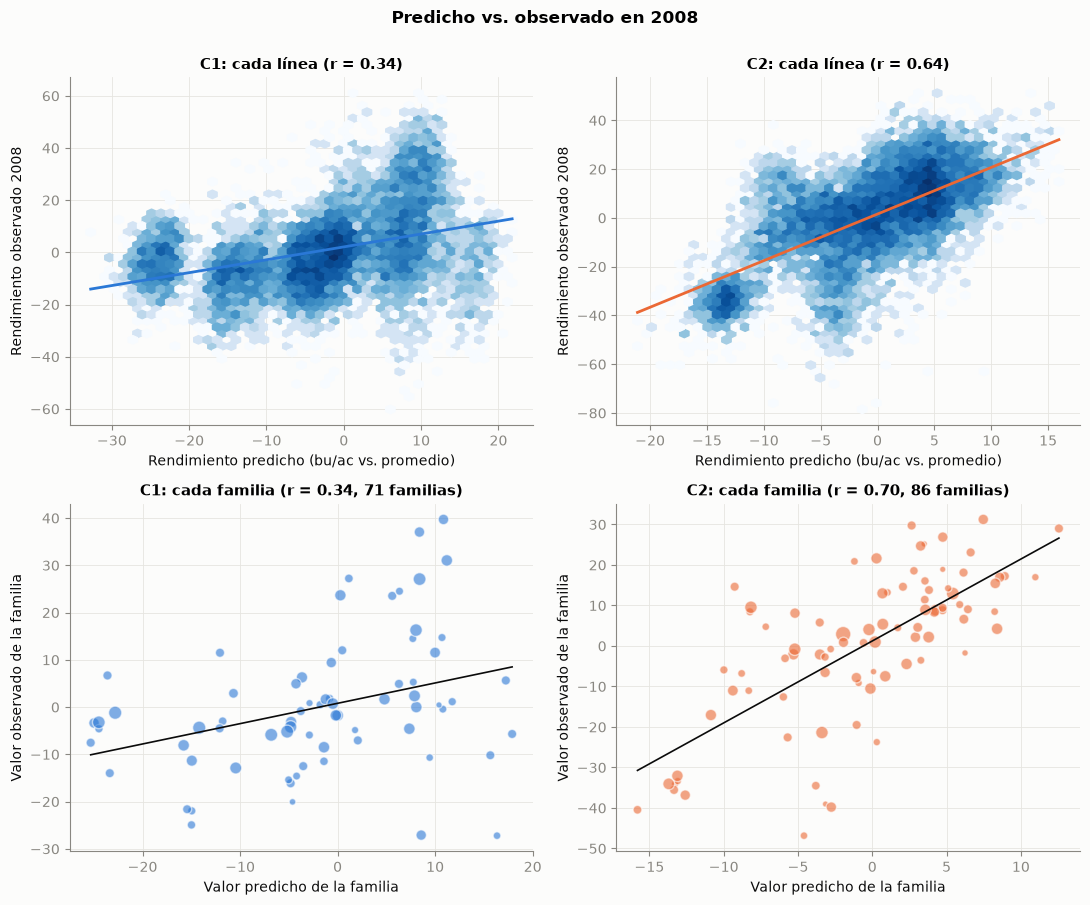

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for j, c in enumerate(CLUSTERS):
    g = K[K.CLUSTER == c]
    ax = axes[0, j]
    hb = ax.hexbin(g.YLD_PRED, g.YLD_OBS_BLUE, gridsize=45, bins="log", cmap="Blues", mincnt=1)
    m, b = np.polyfit(g.YLD_PRED, g.YLD_OBS_BLUE, 1)
    xs = np.array([g.YLD_PRED.min(), g.YLD_PRED.max()])
    ax.plot(xs, m * xs + b, color=COL[c], lw=2)
    ax.set_title(f"{c}: cada línea (r = {H[c]['r_lines']:.2f})")
    ax.set_xlabel("Rendimiento predicho (bu/ac vs. promedio)"); ax.set_ylabel("Rendimiento observado 2008")
    f = g.groupby("POP").agg(p=("YLD_PRED", "mean"), o=("YLD_OBS_BLUE", "mean"), n=("YLD_PRED", "size"))
    ax = axes[1, j]
    ax.scatter(f.p, f.o, s=f.n / 2, color=COL[c], alpha=0.6, edgecolor="white")
    m, b = np.polyfit(f.p, f.o, 1)
    xs = np.array([f.p.min(), f.p.max()]); ax.plot(xs, m * xs + b, color=INK, lw=1.2)
    ax.set_title(f"{c}: cada familia (r = {H[c]['r_family']:.2f}, {len(f)} familias)")
    ax.set_xlabel("Valor predicho de la familia"); ax.set_ylabel("Valor observado de la familia")
plt.suptitle("Predicho vs. observado en 2008", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

**Qué muestra:** arriba, la nube de cada línea es ancha (el ruido de campo es grande), pero la pendiente es positiva en ambos clusters. Abajo, la relación entre familias es más clara, sobre todo en C2. El punto siguiente es cuánto de eso es mérito genético y cuánto es el tester.

## 2. ¿Es estable en el tiempo? Validación hacia adelante 2004–2008

Cada año se entrena con los años anteriores y se predicen las familias nuevas. Si la exactitud cambia mucho de un año a otro, una sola cifra puede engañar.

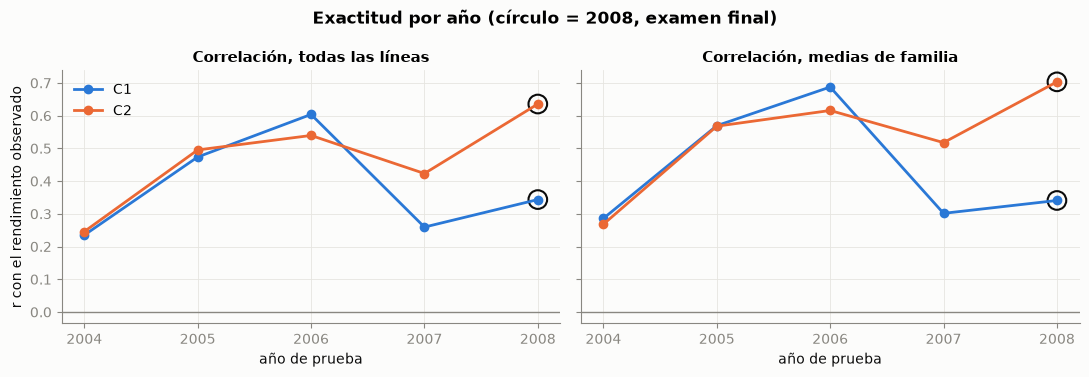

r_between_pops       r_overall      
cluster             C1    C2        C1    C2
year                                        
2004              0.29  0.27      0.23  0.25
2005              0.57  0.57      0.47  0.50
2006              0.69  0.62      0.60  0.54
2007              0.30  0.52      0.26  0.42
2008              0.34  0.70      0.34  0.64

In [5]:
m = "Stage 2 total (family + within)"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, metric, title in zip(axes, ["r_overall", "r_between_pops"], ["Correlación, todas las líneas", "Correlación, medias de familia"]):
    for c in CLUSTERS:
        d = S[(S.model == m) & (S.cluster == c)].sort_values("year")
        ax.plot(d.year, d[metric], "o-", color=COL[c], lw=2, ms=6, label=c)
        ax.scatter(d[d.holdout].year, d[d.holdout][metric], s=180, facecolors="none", edgecolors=INK, lw=1.5)
    ax.axhline(0, color=MUTED, lw=1); ax.set_title(title); ax.set_xticks(range(2004, 2009)); ax.set_xlabel("año de prueba")
axes[0].set_ylabel("r con el rendimiento observado"); axes[0].legend()
plt.suptitle("Exactitud por año (círculo = 2008, examen final)", fontweight="bold"); plt.tight_layout(); plt.show()
S[(S.model == m)].pivot_table(index="year", columns="cluster", values=["r_overall", "r_between_pops"]).round(2)

**Qué muestra:** la exactitud entre familias varía bastante de un año a otro (en C1 entre ~0.3 y ~0.7). Con 50–80 familias por año, cada año es una muestra pequeña. **Por eso 2008 solo no basta**: el resultado esperable para un año futuro es el promedio con esa dispersión.

## 3. ¿Cuánto de la exactitud es el tester?

Todas las líneas de una familia comparten tester. Si el modelo aprende qué testers rinden más, gana correlación entre familias sin decir nada de la calidad genética de las líneas.

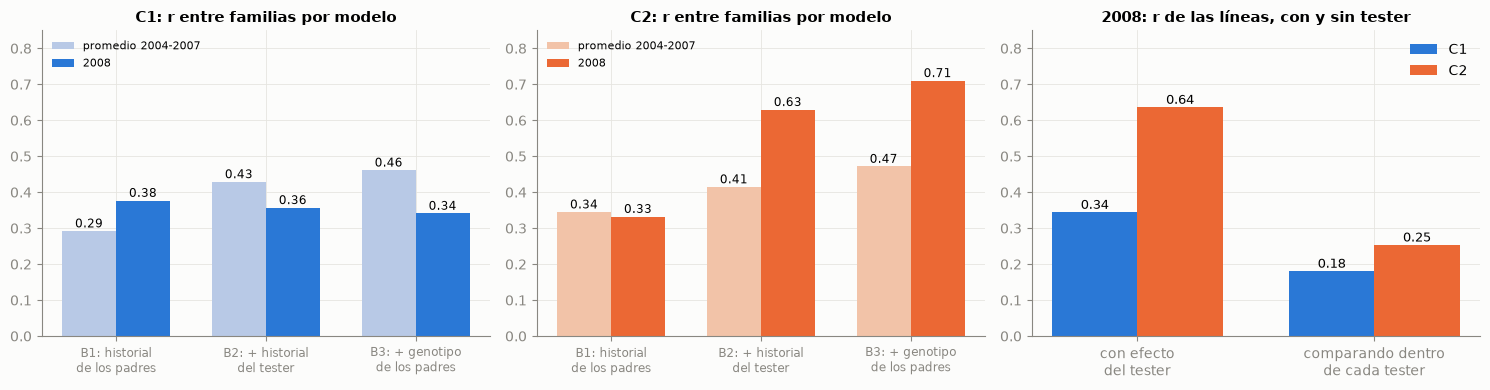

In [6]:
names = {"B1 parent history (family only)": "B1: historial\nde los padres",
         "B2 parent history + tester (family only)": "B2: + historial\ndel tester",
         "B3 genomic family model (family only)": "B3: + genotipo\nde los padres"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 1, 1]})
for ax, c in zip(axes[:2], CLUSTERS):
    d = S[(S.cluster == c) & S.model.isin(names)]
    val = d[~d.holdout].groupby("model").r_between_pops.mean().reindex(names)
    hold = d[d.holdout].groupby("model").r_between_pops.mean().reindex(names)
    x = np.arange(len(names)); w = 0.36
    b1 = ax.bar(x - w / 2, val, w, color="#b8c9e6" if c == "C1" else "#f2c3a8", label="promedio 2004-2007")
    b2 = ax.bar(x + w / 2, hold, w, color=COL[c], label="2008")
    for b in list(b1) + list(b2):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.2f}", ha="center", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(names.values(), fontsize=8.5); ax.set_ylim(0, 0.85)
    ax.set_title(f"{c}: r entre familias por modelo"); ax.legend(fontsize=8, loc="upper left")
ax = axes[2]
x = np.arange(2); w = 0.36
for i, c in enumerate(CLUSTERS):
    vals = [H[c]["r_lines"], H[c]["r_lines_within_tester"]]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, color=COL[c], label=c)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["con efecto\ndel tester", "comparando dentro\nde cada tester"]); ax.set_ylim(0, 0.85)
ax.set_title("2008: r de las líneas, con y sin tester"); ax.legend()
plt.tight_layout(); plt.show()

**Qué muestra:** en C2, pasar de B1 a B2 (agregar el historial del tester) casi duplica la correlación en 2008. Eso no es mérito de las líneas. Al comparar dentro de cada tester, la exactitud cae en ambos clusters (derecha). **Este es el resultado más importante para presentar con honestidad**: la exactitud atribuible a la genética de las líneas es mucho menor que el titular.

## 4. La decisión: ¿cuánto se gana al avanzar solo una parte de las líneas?

Se ordenan las líneas por el rendimiento predicho y se avanza el x% mejor. Curvas con intervalo del 95% por remuestreo de familias.

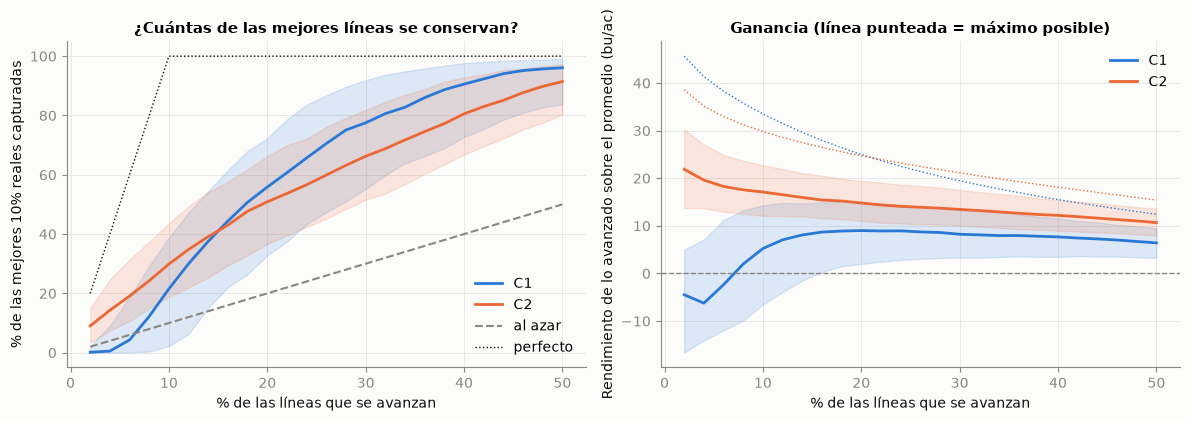

,cluster,avanzar,captura_mejores_10,ganancia_bu,ganancia_maxima_bu
0,C1,6%,4%,-2.4,38.3
1,C1,10%,22%,5.2,33.5
2,C1,20%,56%,9.0,25.0
3,C1,30%,78%,8.2,19.5
4,C1,50%,96%,6.4,12.4
5,C2,6%,19%,18.3,32.9
6,C2,10%,30%,17.1,29.8
7,C2,20%,51%,14.8,24.7
8,C2,30%,66%,13.4,21.1
9,C2,50%,91%,10.7,15.4


In [7]:
FRACS = np.linspace(0.02, 0.5, 25)


def curves(g, n_boot=300, seed=1):
    p, o = g.YLD_PRED.to_numpy(), g.YLD_OBS_BLUE.to_numpy()
    fam = [np.where(g.POP.to_numpy() == f)[0] for f in g.POP.unique()]

    def one(pp, oo):
        n = len(oo)
        order = np.argsort(-pp)
        kt = int(round(n * 0.10))
        is_true = np.zeros(n, bool); is_true[np.argsort(-oo)[:kt]] = True
        ks = np.maximum(1, np.round(FRACS * n).astype(int))
        recall = np.cumsum(is_true[order])[ks - 1] / kt
        gain = np.cumsum(oo[order])[ks - 1] / ks - oo.mean()
        return recall, gain

    rec, gain = one(p, o)
    rng = np.random.default_rng(seed)
    bs = [one(p[idx], o[idx]) for idx in (np.concatenate([fam[i] for i in rng.integers(0, len(fam), len(fam))]) for _ in range(n_boot))]
    R = np.array([b[0] for b in bs]); G = np.array([b[1] for b in bs])
    ks = np.maximum(1, np.round(FRACS * len(o)).astype(int))
    gmax = np.cumsum(np.sort(o)[::-1])[ks - 1] / ks - o.mean()
    return dict(recall=rec, gain=gain, recall_ci=np.percentile(R, [2.5, 97.5], axis=0), gain_ci=np.percentile(G, [2.5, 97.5], axis=0), gmax=gmax)


CURV = {c: curves(K[K.CLUSTER == c].reset_index(drop=True)) for c in CLUSTERS}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for c in CLUSTERS:
    cv = CURV[c]
    axes[0].plot(FRACS * 100, cv["recall"] * 100, color=COL[c], lw=2, label=c)
    axes[0].fill_between(FRACS * 100, cv["recall_ci"][0] * 100, cv["recall_ci"][1] * 100, color=COL[c], alpha=0.15)
    axes[1].plot(FRACS * 100, cv["gain"], color=COL[c], lw=2, label=c)
    axes[1].fill_between(FRACS * 100, cv["gain_ci"][0], cv["gain_ci"][1], color=COL[c], alpha=0.15)
    axes[1].plot(FRACS * 100, cv["gmax"], color=COL[c], lw=1, ls=":")
axes[0].plot(FRACS * 100, FRACS * 100, color=MUTED, ls="--", label="al azar")
axes[0].plot(FRACS * 100, np.minimum(FRACS / 0.10, 1) * 100, color=INK, ls=":", lw=1, label="perfecto")
axes[0].set_xlabel("% de las líneas que se avanzan"); axes[0].set_ylabel("% de las mejores 10% reales capturadas"); axes[0].legend()
axes[0].set_title("¿Cuántas de las mejores líneas se conservan?")
axes[1].axhline(0, color=MUTED, ls="--", lw=1)
axes[1].set_xlabel("% de las líneas que se avanzan"); axes[1].set_ylabel("Rendimiento de lo avanzado sobre el promedio (bu/ac)")
axes[1].set_title("Ganancia (línea punteada = máximo posible)"); axes[1].legend()
plt.tight_layout(); plt.show()

tab = []
for c in CLUSTERS:
    for q in BUDGETS:
        i = int(np.argmin(np.abs(FRACS - q)))
        tab.append(dict(cluster=c, avanzar=f"{int(FRACS[i]*100)}%", captura_mejores_10=f"{CURV[c]['recall'][i]*100:.0f}%",
                        ganancia_bu=round(CURV[c]["gain"][i], 1), ganancia_maxima_bu=round(CURV[c]["gmax"][i], 1)))
pd.DataFrame(tab)

**Qué muestra:** en ambos clusters la curva queda claramente por encima de la diagonal del azar, pero **lejos de la perfecta**, y los intervalos son amplios. Con presupuestos chicos la incertidumbre es grande: en C1, si se avanza menos de ~8% de las líneas, la ganancia esperada no supera al azar (la banda incluye valores negativos). Al avanzar una fracción mayor el resultado es más estable, aunque se gana menos por línea. Esta es la figura que más se acerca a la decisión real: cuántas parcelas se conservan y qué ganancia se espera.

In [8]:
st = strat.assign(split=np.where(strat.year == 2008, "2008", "validación 2004-07"))
order = ["Random", "Family prediction only", "Total prediction, one list", "Two-step: top 30% families, best siblings"]
piv = st.pivot_table(index="strategy", columns=["split", "cluster"], values="gain_pct_of_max").reindex(order).round(0)
piv.index = ["Al azar", "Solo predicción de familia", "Una lista (familia + dentro)", "Dos pasos: 30% mejores familias,\nluego mejores hermanos"]
display(Markdown("**% de la ganancia máxima al avanzar el 10% de las líneas, según la estrategia** (validación = promedio 2004–2007):"))
piv

**% de la ganancia máxima al avanzar el 10% de las líneas, según la estrategia** (validación = promedio 2004–2007):

split                                               2008        \
cluster                                               C1    C2   
Al azar                                              2.0  -0.0   
Solo predicción de familia                          25.0  59.0   
Una lista (familia + dentro)                        16.0  57.0   
Dos pasos: 30% mejores familias,\nluego mejores...  27.0  51.0   

split                                              validación 2004-07        
cluster                                                            C1    C2  
Al azar                                                           0.0  -0.0  
Solo predicción de familia                                       23.0  30.0  
Una lista (familia + dentro)                                     29.0  30.0  
Dos pasos: 30% mejores familias,\nluego mejores...               36.0  31.0

## 5. ¿Se puede confiar en las probabilidades y los intervalos?

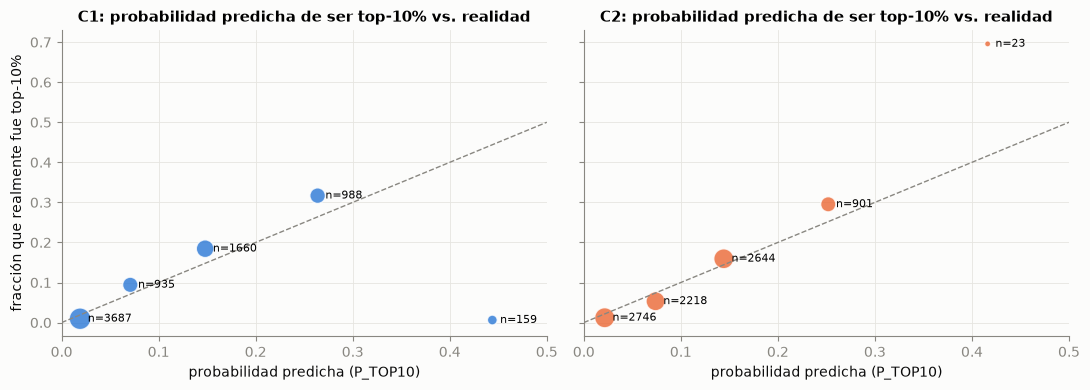

Cobertura del intervalo de 90% en 2008: {'C1': 0.84, 'C2': 0.84}


In [9]:
v8 = vc[(vc.TRAIT == "YLD_BE") & (vc.YEAR == 2008)].set_index("CLUSTER").PEV_MEAN
K2 = K.copy()
K2["tot"] = np.sqrt(K2.YLD_PRED_SD ** 2 + K2.CLUSTER.map(v8))
K2["inside90"] = (K2.YLD_OBS_BLUE - K2.YLD_PRED).abs() < 1.645 * K2.tot
cut = K2.groupby("CLUSTER").YLD_OBS_BLUE.transform(lambda s: s.quantile(0.9))
K2["truly_top10"] = K2.YLD_OBS_BLUE >= cut
bins = [0, 0.05, 0.1, 0.2, 0.4, 1]
K2["bin"] = pd.cut(K2.P_TOP10, bins, labels=["<5%", "5-10%", "10-20%", "20-40%", ">40%"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, c in zip(axes, CLUSTERS):
    t = K2[K2.CLUSTER == c].groupby("bin", observed=True).agg(n=("LINE_ID", "size"), pred=("P_TOP10", "mean"), obs=("truly_top10", "mean"))
    ax.plot([0, 0.5], [0, 0.5], color=MUTED, ls="--", lw=1)
    ax.scatter(t.pred, t.obs, s=np.sqrt(t.n) * 4, color=COL[c], alpha=0.8, edgecolor="white")
    for _, r in t.iterrows():
        ax.text(r.pred + 0.008, r.obs, f"n={int(r.n)}", fontsize=8, va="center")
    ax.set_title(f"{c}: probabilidad predicha de ser top-10% vs. realidad")
    ax.set_xlabel("probabilidad predicha (P_TOP10)"); ax.set_xlim(0, 0.5)
axes[0].set_ylabel("fracción que realmente fue top-10%")
plt.tight_layout(); plt.show()
print("Cobertura del intervalo de 90% en 2008:", K2.groupby("CLUSTER").inside90.mean().round(2).to_dict())

**Qué muestra:** las probabilidades bajas y medias son razonablemente fiables (puntos cerca de la diagonal). Los intervalos de 90% cubren cerca del 84% en 2008, un poco estrechos. El grupo de mayor probabilidad es poco fiable: en C1 (159 líneas) se predijo ~44% y solo ~1% resultó top-10%; en C2 ese grupo es muy pequeño (23 líneas). Estos grupos vienen de pocas familias, y si una familia se predice mal todos sus hermanos fallan juntos. Es una razón concreta para repartir lo avanzado entre varias familias y no fiarse de las probabilidades más altas.

## 6. Dentro de una familia: el techo lo pone el ruido

Entre hermanos comparten padres y sitios, así que la comparación es limpia. Pero lo que se observa de cada línea es ruidoso, y eso limita cualquier modelo.

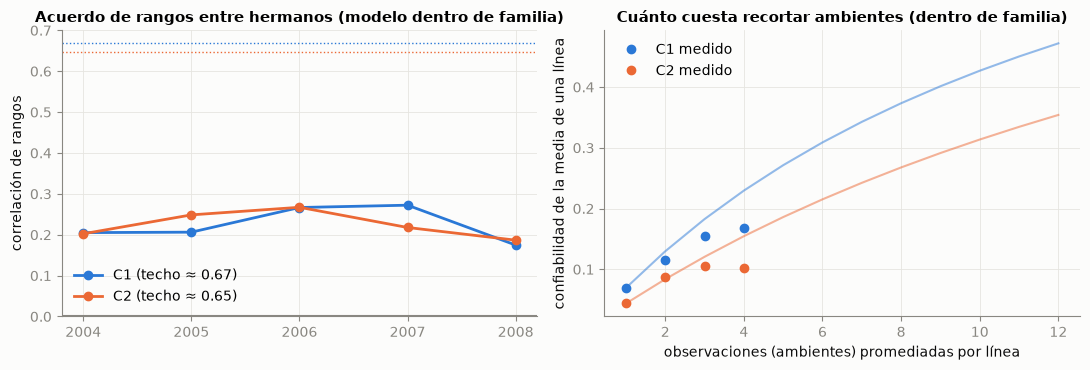

Heredabilidad de una línea frente a sus hermanos (mediana 2001-2007): {'C1': 0.45, 'C2': 0.42} -> correlación máxima posible contra lo observado: {'C1': 0.67, 'C2': 0.65}


In [10]:
W = S[S.model == "Within-family model on DEV"]
h2 = vc[(vc.TRAIT == "YLD_BE") & vc.YEAR.between(2001, 2007)].groupby("CLUSTER").H2_LINE_WITHIN.median()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for c in CLUSTERS:
    d = W[W.cluster == c].sort_values("year")
    axes[0].plot(d.year, d.rho_within_pops, "o-", color=COL[c], lw=2, label=f"{c} (techo ≈ {np.sqrt(h2[c]):.2f})")
axes[0].set_ylim(0, 0.7); axes[0].axhline(0, color=MUTED); axes[0].set_xticks(range(2004, 2009)); axes[0].legend()
axes[0].set_title("Acuerdo de rangos entre hermanos (modelo dentro de familia)"); axes[0].set_ylabel("correlación de rangos")
for c in CLUSTERS:
    axes[0].axhline(np.sqrt(h2[c]), color=COL[c], ls=":", lw=1)
fin_ok = (FIN / "reliability_by_obs.csv").exists()
if fin_ok:
    R = pd.read_csv(FIN / "reliability_by_obs.csv")
    R = R[R.n_lines >= 5000]   # 5+ observations leaves only ~1 300 selected lines: not comparable
    mm = np.arange(1, 13)
    for c in CLUSTERS:
        d = R[R.cluster == c]
        rho = d.loc[d.m == 1, "reliability"].iloc[0]
        axes[1].plot(d.m, d.reliability, "o", color=COL[c], label=f"{c} medido")
        axes[1].plot(mm, mm * rho / (1 + (mm - 1) * rho), "-", color=COL[c], alpha=0.5)
    axes[1].set_xlabel("observaciones (ambientes) promediadas por línea"); axes[1].set_ylabel("confiabilidad de la media de una línea")
    axes[1].set_title("Cuánto cuesta recortar ambientes (dentro de familia)"); axes[1].legend()
plt.tight_layout(); plt.show()
print("Heredabilidad de una línea frente a sus hermanos (mediana 2001-2007):", h2.round(2).to_dict(), "-> correlación máxima posible contra lo observado:", np.sqrt(h2).round(2).to_dict())

**Qué muestra (izquierda):** el acuerdo de rangos entre hermanos es de ~0.2 en ambos clusters, contra un techo de ~0.65 que fija el ruido. Es una señal real, consistente entre años, y modesta. **(Derecha)** la confiabilidad de la media de una línea es baja y crece con el número de ambientes, con rendimientos decrecientes (C1: 0.07 con 1 observación y 0.17 con 4; C2: 0.04 y 0.10). La línea continua es la curva teórica de Spearman-Brown; los puntos medidos quedan por debajo o cerca. Recortar ambientes cuesta exactitud, y como el ruido domina, ningún número razonable de ambientes lleva la confiabilidad cerca de 1.

## 7. ¿Qué datos se limpiaron, imputaron o borraron?

In [11]:
def cl(c):
    p, lv, gn = qc["phenotypes"][c], qc["line_values"][c]["YLD_BE"], qc["genotypes"][c]
    return {
        "Parcelas crudas": f"{p['rows_raw']:,}",
        "Valores fuera de rango → NA (todos los rasgos)": f"{sum(p['values_out_of_bounds'].values()):,}",
        "Filas sin ningún rasgo (borradas)": f"{p['rows_without_traits_dropped']:,}",
        "Filas con tester desconocido (agrupadas)": f"{p['rows_missing_tester']:,} ({100*p['rows_missing_tester']/p['rows_raw']:.1f}%)",
        "IDs de línea unificados (2 formatos)": f"{p['line_ids_unified_from_2_formats']:,}",
        "Rendimiento: parcelas atípicas descartadas": f"{lv['outliers_removed']:,} de {lv['plots_in']:,}",
        "Rendimiento: ambientes excluidos por mal ensayo": f"{lv['envs_excluded']} de {lv['envs_excluded'] + lv['envs_used']}",
        "Rendimiento: parcelas usadas": f"{100*lv['plots_used']/lv['plots_in']:.1f}%",
        "SNPs observados por línea (mediana, de 2 911)": f"{gn['median_obs_snps_per_line']:.0f}",
        "Genotipo: concordancia al reconstruir (llamadas tapadas)": f"{100*gn['mask_validation']['concordance']:.0f}%  (azar ≈ 50%)",
        "Genotipo: líneas con algún cromosoma sin marcadores": f"{gn['lines_with_chr_without_obs_pct']:.1f}%",
        "Genotipo: celdas rellenadas con la media del cluster": f"{100*gn['residual_cells_filled_with_cluster_mean']/(gn['n_lines']*2911):.1f}%",
    }
pd.DataFrame({c: cl(c) for c in CLUSTERS})

,C1,C2
Parcelas crudas,"536,936","535,340"
Valores fuera de rango → NA (todos los rasgos),481,209
Filas sin ningún rasgo (borradas),94,125
Filas con tester desconocido (agrupadas),"31,300 (5.8%)","9,858 (1.8%)"
IDs de línea unificados (2 formatos),667,0
Rendimiento: parcelas atípicas descartadas,"270 de 516,032","271 de 511,983"
Rendimiento: ambientes excluidos por mal ensayo,42 de 1177,53 de 1085
Rendimiento: parcelas usadas,97.2%,95.9%
"SNPs observados por línea (mediana, de 2 911)",69,68
Genotipo: concordancia al reconstruir (llamadas tapadas),75% (azar ≈ 50%),76% (azar ≈ 50%)


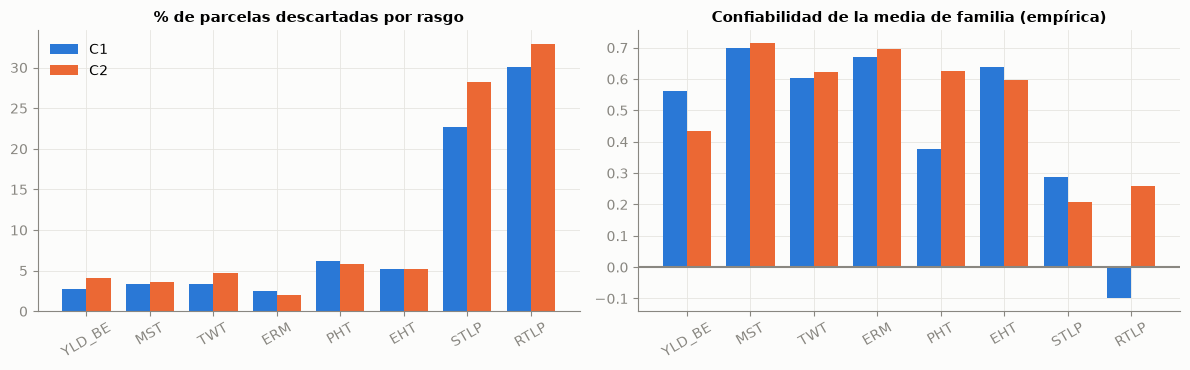

In [12]:
traits = ["YLD_BE", "MST", "TWT", "ERM", "PHT", "EHT", "STLP", "RTLP"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(traits)); w = 0.38
for ax, key, title, fn in zip(axes, ["removed", "rel"], ["% de parcelas descartadas por rasgo", "Confiabilidad de la media de familia (empírica)"],
                              [lambda t, c: 100 * (1 - qc["line_values"][c][t]["plots_used"] / qc["line_values"][c][t]["plots_in"]),
                               lambda t, c: qc["line_values"][c][t]["pop_means_reliability_empirical"]]):
    for i, c in enumerate(CLUSTERS):
        ax.bar(x + (i - 0.5) * w, [fn(t, c) for t in traits], w, color=COL[c], label=c)
    ax.set_xticks(x); ax.set_xticklabels(traits, rotation=30); ax.set_title(title)
axes[1].axhline(0, color=MUTED); axes[0].legend()
plt.tight_layout(); plt.show()

**Qué muestra:** el rendimiento, la humedad y el peso de grano pierden poco (3–5% de las parcelas) y sus medias de familia tienen confiabilidad de 0.43 a 0.71. El acame (STLP, RTLP) pierde 23–33% de las parcelas y su confiabilidad es baja (de −0.10 a 0.29): **no son rasgos utilizables**.

**Tres cosas a declarar:**
1. **Los genotipos son en su mayoría inferidos.** Cada línea tiene ~69 SNPs observados de 2 911; el resto se reconstruye por herencia de los padres, con ~75% de concordancia. Sirve para predecir, pero un "SNP con efecto" es en realidad un tramo de cromosoma.
2. **La exclusión de ambientes malos usa los mismos datos** que después sirven de "respuesta correcta" en 2008. Es una práctica estándar (3–4% de los ambientes), pero hay que decirlo.
3. **Los testers desconocidos** se agrupan como uno solo, aunque probablemente son varios distintos.

## 8. Marcadores: ¿hay regiones con efecto que se repita?

Efecto de cada SNP **dentro de familia** (para no confundirlo con la estructura de las poblaciones), estimado con los años ≤ 2007 y comparado con el efecto medido de forma independiente en 2008. Solo C1 (análisis hecho sobre los archivos de C1).

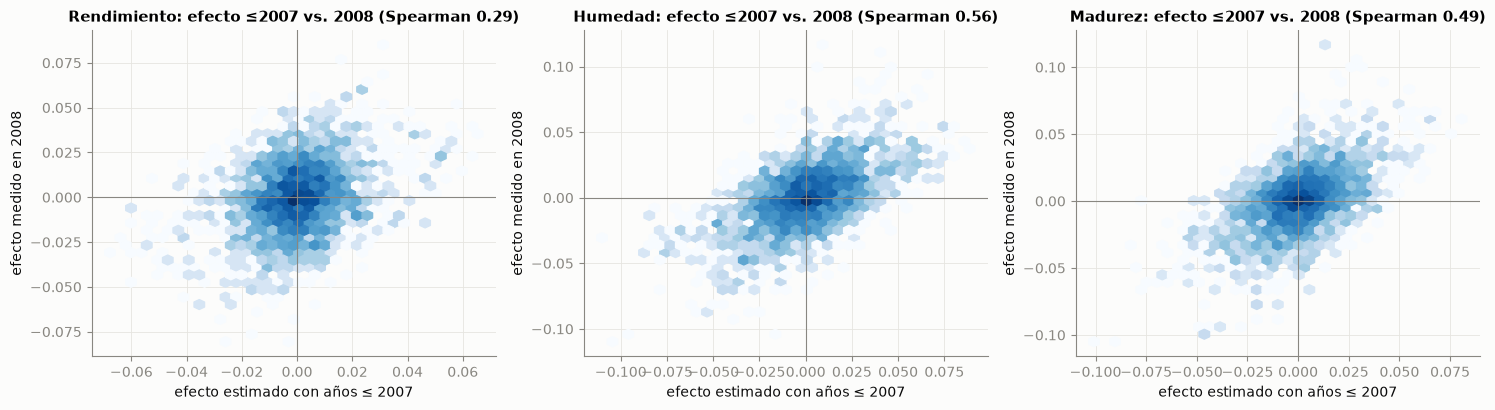

SNPs con |t| > 5 en ≤2007 cuyo signo y magnitud se repiten en 2008: {'YLD_BE': 95, 'MST': 300, 'ERM': 190, 'TWT': 232}


In [13]:
fmark = MINE / "snp_effects_all_traits.csv"
if fmark.exists():
    T = pd.read_csv(fmark)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, tr, name in zip(axes, ["YLD_BE", "MST", "ERM"], ["Rendimiento", "Humedad", "Madurez"]):
        rho = stats.spearmanr(T[f"{tr}_r"], T[f"{tr}_r2008"])[0]
        ax.hexbin(T[f"{tr}_r"], T[f"{tr}_r2008"], gridsize=35, bins="log", cmap="Blues", mincnt=1)
        ax.axhline(0, color=MUTED, lw=0.8); ax.axvline(0, color=MUTED, lw=0.8)
        ax.set_title(f"{name}: efecto ≤2007 vs. 2008 (Spearman {rho:.2f})")
        ax.set_xlabel("efecto estimado con años ≤ 2007"); ax.set_ylabel("efecto medido en 2008")
    plt.tight_layout(); plt.show()
    print("SNPs con |t| > 5 en ≤2007 cuyo signo y magnitud se repiten en 2008:",
          {t: int(T[f"{t}_candidate"].sum()) for t in ["YLD_BE", "MST", "ERM", "TWT"]})

**Qué muestra:** los efectos por SNP se repiten entre años de forma **positiva pero modesta** (humedad y madurez más que rendimiento). No hay un solo SNP dominante: el rendimiento es **poligénico**, con muchos efectos pequeños. Con el requisito estricto de "descubrir en ≤2005, replicar en 2006–07 y probar en 2008", las regiones descubiertas predicen 2008 apenas algo mejor que conjuntos de SNPs al azar del mismo tamaño (valores p entre 0.10 y 0.26). Conclusión honesta: **la señal está repartida en todo el genoma, y no hay una lista corta de regiones que resuma la predicción**.

In [14]:
fe = MINE / "proposal2007_evidence.csv"
if fe.exists():
    E = pd.read_csv(fe)
    pd.set_option("display.max_colwidth", 200)
    display(Markdown("**Regiones encontradas con la regla de fin de 2007 (descubrimiento 2000–05, replicación 2006–07) y su predicción en 2008, dentro de familia:**"))
    display(E[E.claim.str.contains("Regions found")][["claim", "value", "uncertainty"]])

**Regiones encontradas con la regla de fin de 2007 (descubrimiento 2000–05, replicación 2006–07) y su predicción en 2008, dentro de familia:**

,claim,value,uncertainty
0,Regions found <=2007 for YLD predict 2008 (within-family r),0.085,95% CI 0.052 to 0.119; p vs random SNPs = 0.258
1,Regions found <=2007 for YLD_ADJ predict 2008 (within-family r),0.088,95% CI 0.059 to 0.123; p vs random SNPs = 0.097
2,Regions found <=2007 for ERM predict 2008 (within-family r),0.181,95% CI 0.141 to 0.224; p vs random SNPs = 0.129
3,Regions found <=2007 for MST predict 2008 (within-family r),0.212,95% CI 0.176 to 0.248; p vs random SNPs = 0.097


## 9. Sitios: ¿se puede decir de antemano cuáles evalúan mejor?

Se midió qué tan bien discrimina entre líneas cada sitio-año (correlación dentro de familia entre lo medido ahí y el resto del año).

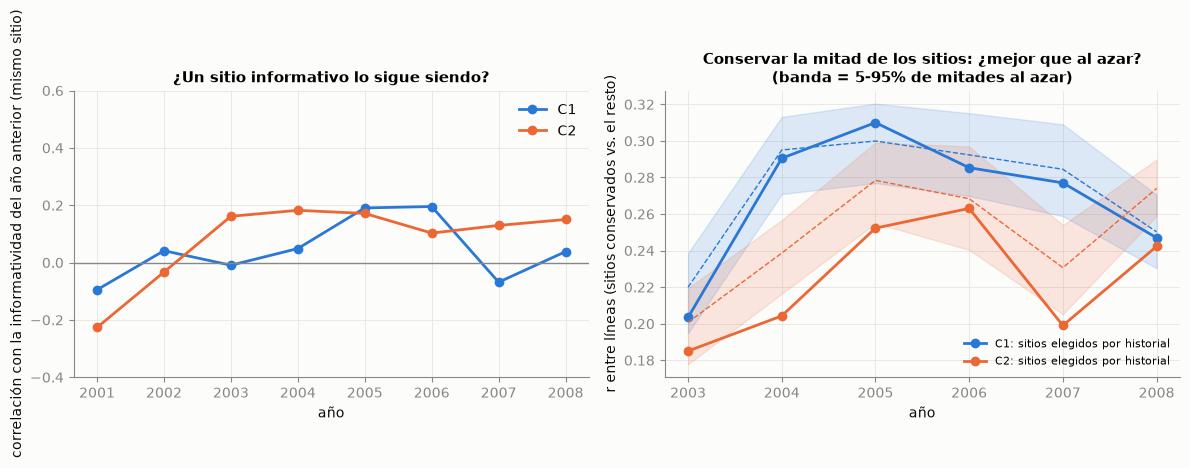

**Qué distinguió a los sitios que los mejoradores conservaron de un año al siguiente** (tamaño del ensayo el año anterior, promedio de los años):

,años,obs_conservados,obs_descartados,años_con_p_menor_005
cluster,,,,
C1,8,512.0,380.0,4
C2,8,527.0,385.0,3


In [15]:
fin_ok = (FIN / "site_persistence.csv").exists()
if fin_ok:
    P = pd.read_csv(FIN / "site_persistence.csv"); B = pd.read_csv(FIN / "site_backtest.csv"); Rt = pd.read_csv(FIN / "site_retention.csv")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for c in CLUSTERS:
        d = P[P.cluster == c]
        axes[0].plot(d.year, d["corr"], "o-", color=COL[c], lw=2, label=c)
    axes[0].axhline(0, color=MUTED, lw=1); axes[0].set_ylim(-0.4, 0.6); axes[0].set_xlabel("año"); axes[0].legend()
    axes[0].set_ylabel("correlación con la informatividad del año anterior (mismo sitio)")
    axes[0].set_title("¿Un sitio informativo lo sigue siendo?")
    for c in CLUSTERS:
        d = B[B.cluster == c].sort_values("year")
        axes[1].fill_between(d.year, d.r_random_p05, d.r_random_p95, color=COL[c], alpha=0.15)
        axes[1].plot(d.year, d.r_random_mean, "--", color=COL[c], lw=1)
        axes[1].plot(d.year, d.r_informative, "o-", color=COL[c], lw=2, label=f"{c}: sitios elegidos por historial")
    axes[1].set_xlabel("año"); axes[1].set_ylabel("r entre líneas (sitios conservados vs. el resto)")
    axes[1].set_title("Conservar la mitad de los sitios: ¿mejor que al azar?\n(banda = 5-95% de mitades al azar)"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    kept = Rt.groupby("cluster").agg(años=("year", "size"), obs_conservados=("n_obs_kept", "mean"), obs_descartados=("n_obs_dropped", "mean"),
                                      años_con_p_menor_005=("p_n_obs", lambda s: int((s < 0.05).sum())))
    display(Markdown("**Qué distinguió a los sitios que los mejoradores conservaron de un año al siguiente** (tamaño del ensayo el año anterior, promedio de los años):"))
    display(kept.round(0))

**Qué muestra:** la informatividad de un sitio se repite poco de un año al siguiente (en C1 cerca de 0; en C2 débilmente positiva, ~0.15, desde 2003). Elegir la mitad de los sitios con su historial **no supera al azar**: en C1 los puntos caen dentro de la banda todos los años, y en C2 incluso quedan por debajo en 4 de 6 años. Lo que parece hacer informativo a un sitio es el clima y manejo de ese año, que no se conoce en enero.

En cuanto a lo que hicieron los mejoradores: en los 8 años y en ambos clusters, los sitios que conservaron de un año al siguiente eran en promedio más grandes (C1: 512 vs. 380 observaciones; C2: 527 vs. 385), con diferencia significativa en 3–4 de 8 años. En informatividad no se distinguían (salvo C2 en 2002). **No se puede afirmar con estos datos que unos sitios sean mejores que otros para evaluar.**

## 10. Qué afirmamos y qué no

**Con respaldo**
- El modelo ordena las líneas mejor que el azar, de forma consistente entre años y en ambos clusters, con una exactitud modesta (ver tabla y curvas de la sección 1 y 4).
- Dentro de una familia, los marcadores separan mejor a los hermanos que el azar (~0.2 de correlación de rangos), cerca de lo que permite el ruido.
- Las probabilidades de la parte baja y media son razonablemente fiables.

**Con reservas**
- La exactitud "entre familias" está inflada por el tester, sobre todo en C2. La cifra sin tester es un límite inferior de la genética.
- Cada año es una muestra pequeña de familias: una sola validación (2008) tiene intervalos amplios.
- Los genotipos son mayormente inferidos por herencia, así que no hay SNPs causales que señalar.

**Sin respaldo con estos datos**
- Un ranking de sitios "mejores" de antemano.
- Una lista corta de haplotipos o regiones que resuma la predicción.
- Cifras combinadas de C1 y C2.

**Sobre el presupuesto:** el reto no fija cuántas parcelas se conservan, así que ninguna fracción es "la" recomendada. La curva de la sección 4 muestra el compromiso: mientras más se recorta, menos se captura de las mejores líneas y mayor es la incertidumbre (en C1, por debajo de ~8% no se supera al azar). Para cualquier presupuesto conviene repartir lo avanzado entre varias familias: la estrategia de dos pasos (mejores familias y, dentro de cada una, mejores hermanos) fue la más consistente en la validación al avanzar el 10%, que es el único presupuesto que se comparó en esa validación.